# Fraud Detection - Feature Engineering & Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [10]:
import pandas as pd
import numpy as np


df = pd.read_csv("../data/processed/merged_fraud.csv")
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,16778240.0,16779263.0,Australia
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,16809984.0,16842751.0,Thailand
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,16843264.0,16843775.0,China
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,16924672.0,16941055.0,China
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,16941056.0,16973823.0,Thailand


In [8]:
df = pd.read_csv("../data/processed/merged_fraud.csv")
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,16778240.0,16779263.0,Australia
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,16809984.0,16842751.0,Thailand
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,16843264.0,16843775.0,China
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,16924672.0,16941055.0,China
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,16941056.0,16973823.0,Thailand


The dataset contains enriched e-commerce transaction data including user behavior and geolocation (country) information.

In [12]:
df.shape

(129146, 14)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129146 entries, 0 to 129145
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 129146 non-null  int64  
 1   signup_time             129146 non-null  str    
 2   purchase_time           129146 non-null  str    
 3   purchase_value          129146 non-null  int64  
 4   device_id               129146 non-null  str    
 5   source                  129146 non-null  str    
 6   browser                 129146 non-null  str    
 7   sex                     129146 non-null  str    
 8   age                     129146 non-null  int64  
 9   ip_address              129146 non-null  float64
 10  class                   129146 non-null  int64  
 11  lower_bound_ip_address  129146 non-null  float64
 12  upper_bound_ip_address  129146 non-null  float64
 13  country                 129146 non-null  str    
dtypes: float64(3), int64(4), str(7)

The dataset contains transaction-level records with numerical, categorical, and datetime features. Data types are checked to ensure correct feature processing.

In [16]:
df.dtypes

user_id                     int64
signup_time                   str
purchase_time                 str
purchase_value              int64
device_id                     str
source                        str
browser                       str
sex                           str
age                         int64
ip_address                float64
class                       int64
lower_bound_ip_address    float64
upper_bound_ip_address    float64
country                       str
dtype: object

Datetime features will be used to extract behavioral patterns such as time-based fraud activity.

In [18]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

In [19]:
df['time_since_signup'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds()

In [20]:
df[['signup_time', 'purchase_time']].dtypes

signup_time      datetime64[us]
purchase_time    datetime64[us]
dtype: object

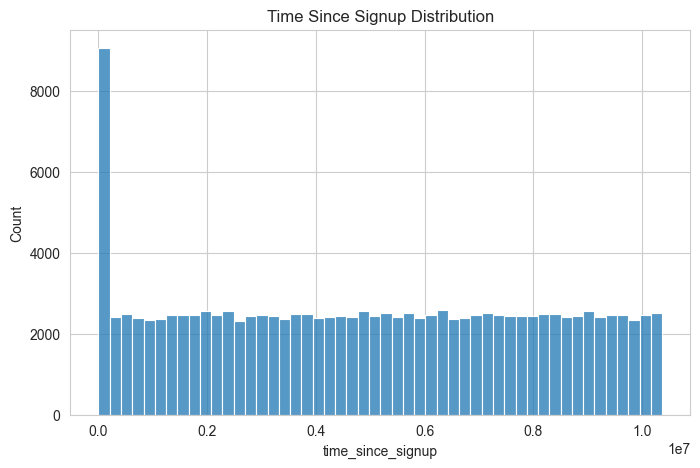

In [21]:
sns.histplot(df['time_since_signup'], bins=50)
plt.title("Time Since Signup Distribution")
plt.show()

Fraudulent transactions often occur shortly after account creation. This feature captures the time gap between signup and purchase to detect suspicious rapid activity.

In [22]:
df['hour_of_day'] = df['purchase_time'].dt.hour

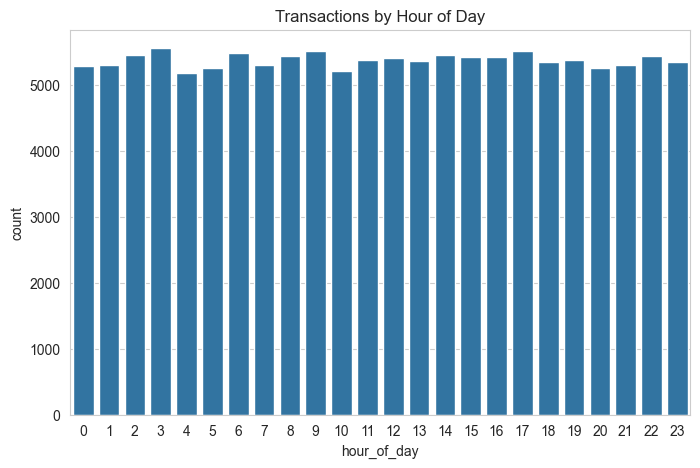

In [23]:
sns.countplot(x='hour_of_day', data=df)
plt.title("Transactions by Hour of Day")
plt.show()

Fraud activity may occur at unusual hours when monitoring systems are less active.

In [24]:
df['day_of_week'] = df['purchase_time'].dt.dayofweek

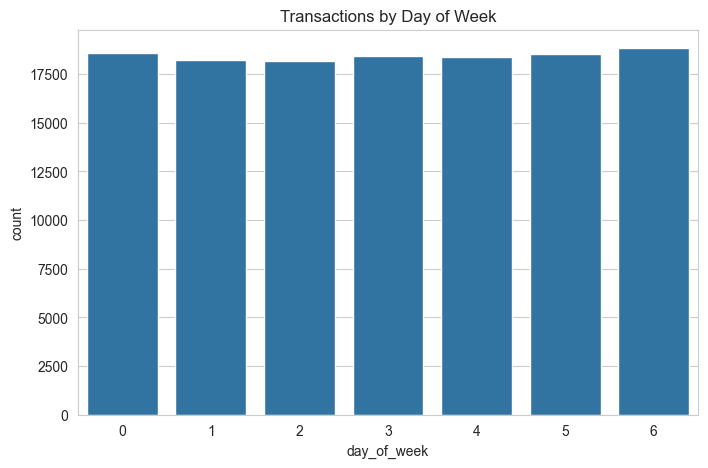

In [25]:
sns.countplot(x='day_of_week', data=df)
plt.title("Transactions by Day of Week")
plt.show()


Weekly transaction patterns help identify abnormal fraud behavior across weekdays and weekends.

In [26]:
user_freq = df['user_id'].value_counts()
df['transaction_count'] = df['user_id'].map(user_freq)

In [27]:
df['transaction_count'].describe()

count    129146.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: transaction_count, dtype: float64

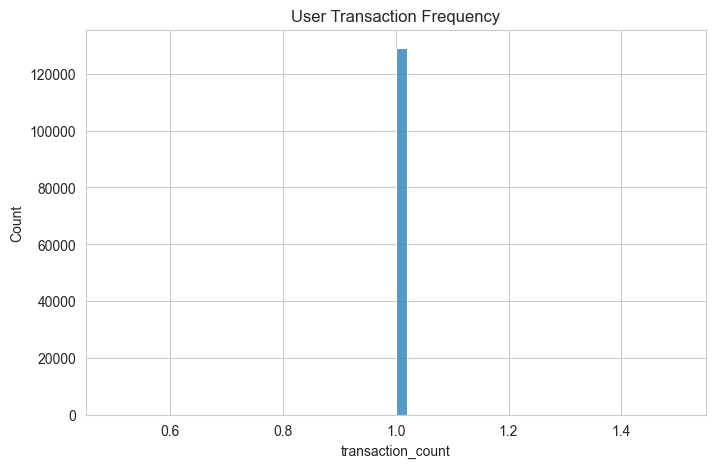

In [28]:
sns.histplot(df['transaction_count'], bins=50)
plt.title("User Transaction Frequency")
plt.show()


Users with unusually high transaction counts may indicate automated or fraudulent activity.

In [29]:
country_fraud = df.groupby('country')['class'].mean().sort_values(ascending=False).head(10)
country_fraud

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

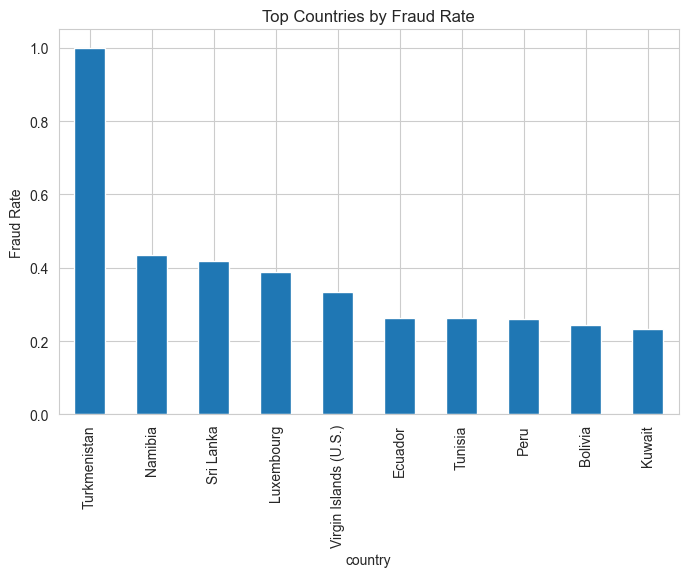

In [30]:
country_fraud.plot(kind='bar')
plt.title("Top Countries by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

Fraud rates vary significantly across countries, showing that geographical location is a strong predictor of fraudulent behavior.

## Feature Engineering Summary

The following features were created to improve fraud detection:

- time_since_signup → detects rapid fraudulent purchases after account creation
- hour_of_day → captures unusual transaction timing
- day_of_week → identifies weekly behavioral patterns
- transaction_count → detects abnormal user activity frequency
- country → captures geographical fraud risk differences

These features convert raw transactional data into meaningful behavioral signals that improve model performance.